# Computer Exercise 5.3 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.3 Simpson's Rule — *균등 분할의 한계, 적응형의 동기*
> **풀이 일자**: Day 19
> **언어**: Python 3 (NumPy / Matplotlib / Pandas)


## 1. 문제 (원문)

> **2.** Apply the composite Simpson rule to three integrands whose *local* behaviour is
> dramatically nonuniform across $[0, 1]$:
> $$
> (a)\;\int_{-1}^{1} \frac{1}{1+25 x^2}\,dx = \frac{2}{5}\arctan 5, \qquad
> (b)\;\int_0^1 \frac{1}{\sqrt{x}}\,dx = 2, \qquad
> (c)\;\int_0^1 e^{-1000 (x-0.5)^2}\,dx \;\approx\; \sqrt{\pi/1000}.
> $$
> For each, tabulate the Simpson error against $n = 4, 8, 16, \ldots, 2^{14}$.
> Compare the *measured* convergence orders with the predicted $\mathcal O(h^4)$, and
> identify *which* features of the integrand break the prediction.

### 한국어 풀이용 정리
- (a) **Runge 함수** — 매끄럽지만 $x = 0$ 근처에 좁은 peak. 차수는 $4$ 지만 *상수가 매우 크다*.
- (b) **끝점 미분 특이점** $1/\sqrt x$ — Euler–Maclaurin 의 *수정항* 이 leading.
  *부드러운* 함수에 대한 $\mathcal O(h^4)$ 가 *깨진다*.
- (c) **매우 좁은 Gaussian** ($\sigma \approx 0.022$) — 매끄럽지만 $f^{(4)}$ 가 *천문학적*.
  $n$ 이 *너무 작으면* Simpson 이 peak 을 *놓친다* — 자릿수 손실 + spurious 결과.

세 케이스를 통해 *왜* 균등 분할 Simpson 만으로는 부족한지를 보여준다.


## 2. 수학적 배경

### 2.1 Simpson 의 *전역* 차수 vs *지역* 비용
오차 표현 $S_n - I = -(b-a) f^{(4)}(\xi) h^4 / 180$ 의 $f^{(4)}$ 가 *국소적으로 크면* —
peak, 첨예한 굴곡, 빠른 진동 — 같은 $h$ 라도 *전역 상수* 가 폭발한다.
차수 $4$ 는 살아남지만 *프리팩터* 가 매우 커져 *유효 $n$* 이 사실상 무용해진다.

### 2.2 끝점 특이점 — 차수 자체의 붕괴
$f(x) = x^{\alpha}$ ($\alpha = -1/2$ 이지만 적분 자체는 유한) 같은 경우, Simpson 의
오차 표현이 요구하는 $f \in C^4$ 가 성립하지 않는다. Euler–Maclaurin 의 *수정항*

$$
S_n - I \;\sim\; \frac{C_\alpha}{n^{\alpha+1}}
$$

이 leading 으로 떠올라, $1/\sqrt x$ 의 경우 $\mathcal O(n^{-1/2})$ — *Simpson 이 사다리꼴보다도 나쁘다*.

### 2.3 좁은 Gaussian — *과소 표집*
$f(x) = e^{-K(x-c)^2}$ 에서 peak 의 폭은 $\sim 1/\sqrt K$. $h$ 가 이보다 *훨씬 크면* Simpson 은
peak 을 거의 만나지 못해 *0 에 가까운* 결과를 내놓는다. $h \le 1/\sqrt K$ 가 되어야 비로소 $\mathcal O(h^4)$
영역에 진입.

### 2.4 한 줄 정리

$$
\boxed{\,
\text{유효 정확도} \approx \frac{(b-a)\,h^4\,\|f^{(4)}\|_\infty}{180}\,}
$$

— 차수는 *전역* 지만 분자의 $\|f^{(4)}\|_\infty$ 가 *국소 현상* 을 모두 짊어진다.


## 3. 풀이 흐름

1. 세 적응형이 *필요한* 피적분 함수와 그 참값을 정의.
2. $n \in \{4, 8, 16, \ldots, 2^{14}\}$ 에 대해 합성 Simpson 오차 계산.
3. 표로 정리해 각 함수의 오차 거동을 직접 본다.
4. log–log 회귀로 *실제* 수렴 차수를 측정 — 이론값과 어긋나는 경우를 식별.
5. semilogy / loglog 한 평면에 세 함수를 겹쳐 그린다 — *교과서적 $\mathcal O(h^4)$* 와의 괴리.
6. 좁은 Gaussian 의 *피적분 함수* 와 *Simpson 의 표집점* 을 함께 시각화 — *왜* 과소 표집이 위험한지.
7. 결과 해석 — 적응형 알고리즘의 *동기* 를 한 줄로 정리.


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6e}")

def simpson(f, a, b, n):
    if n % 2 != 0:
        raise ValueError("Simpson requires even n")
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    w = np.ones(n + 1)
    w[1:-1:2] = 4.0
    w[2:-1:2] = 2.0
    return h / 3.0 * (w * y).sum()

# 적응형이 필요한 세 피적분 함수
problems = [
    ("Runge 1/(1+25 x^2) on [-1,1]",      lambda x: 1.0 / (1.0 + 25.0 * x * x),
        -1.0, 1.0, (2.0 / 5.0) * np.arctan(5.0)),
    ("1/sqrt(x) on (0,1]",                 lambda x: 1.0 / np.sqrt(np.maximum(x, 1e-300)),
        1e-8, 1.0, 2.0 * (1.0 - np.sqrt(1e-8))),
    ("exp(-1000 (x-0.5)^2) on [0,1]",      lambda x: np.exp(-1000.0 * (x - 0.5) ** 2),
        0.0, 1.0, np.sqrt(np.pi / 1000.0) *
                  0.5 * (math.erf(np.sqrt(1000.0) * 0.5) - math.erf(-np.sqrt(1000.0) * 0.5))),
]

ks = np.arange(2, 15)        # n = 4, 8, ..., 16384
ns = 2 ** ks

frames = {}
for name, f, a, b, I in problems:
    rows = []
    prev_err = None
    for n in ns:
        Sn = simpson(f, a, b, int(n))
        err = Sn - I
        ratio = (abs(prev_err) / abs(err)) if (prev_err is not None and abs(err) > 0) else np.nan
        rows.append({"n": int(n), "h": (b - a) / n, "S_n": Sn, "error": err,
                     "|error|": abs(err), "|e_n|/|e_2n|": ratio})
        prev_err = err
    frames[name] = pd.DataFrame(rows)

print("=== Runge ===  (smooth but sharp peak at x=0; should converge with order 4 but large constant)")
frames["Runge 1/(1+25 x^2) on [-1,1]"]


=== Runge ===  (smooth but sharp peak at x=0; should converge with order 4 but large constant)


,n,h,S_n,error,|error|,|e_n|/|e_2n|
0,4,5.000000e-01,5.300619e-01,-1.929841e-02,1.929841e-02,NaN
1,8,2.500000e-01,5.234766e-01,-2.588374e-02,2.588374e-02,7.455805e-01
2,16,1.250000e-01,5.466638e-01,-2.696500e-03,2.696500e-03,9.599015e+00
3,32,6.250000e-02,5.493421e-01,-1.816338e-05,1.816338e-05,1.484580e+02
4,64,3.125000e-02,5.493603e-01,-9.099850e-09,9.099850e-09,1.996009e+03
5,128,1.562500e-02,5.493603e-01,-5.213512e-10,5.213512e-10,1.745436e+01
6,256,7.812500e-03,5.493603e-01,-3.260237e-11,3.260237e-11,1.599121e+01
7,512,3.906250e-03,5.493603e-01,-2.038036e-12,2.038036e-12,1.599695e+01
8,1024,1.953125e-03,5.493603e-01,-1.274536e-13,1.274536e-13,1.599042e+01
9,2048,9.765625e-04,5.493603e-01,-7.993606e-15,7.993606e-15,1.594444e+01


In [2]:
print("=== 1/sqrt(x) ===  (endpoint singularity; should converge SLOWER than O(h^4))")
frames["1/sqrt(x) on (0,1]"]


=== 1/sqrt(x) ===  (endpoint singularity; should converge SLOWER than O(h^4))


,n,h,S_n,error,|error|,|e_n|/|e_2n|
0,4,2.500000e-01,8.347039e+02,8.327041e+02,8.327041e+02,NaN
1,8,1.250000e-01,4.182216e+02,4.162218e+02,4.162218e+02,2.000626e+00
2,16,6.250000e-02,2.100187e+02,2.080189e+02,2.080189e+02,2.000885e+00
3,32,3.125000e-02,1.059442e+02,1.039444e+02,1.039444e+02,2.001252e+00
4,64,1.562500e-02,5.392599e+01,5.192619e+01,5.192619e+01,2.001771e+00
5,128,7.812500e-03,2.793041e+01,2.593061e+01,2.593061e+01,2.002506e+00
6,256,3.906250e-03,1.494216e+01,1.294236e+01,1.294236e+01,2.003545e+00
7,512,1.953125e-03,8.454788e+00,6.454988e+00,6.454988e+00,2.005017e+00
8,1024,9.765625e-04,5.215873e+00,3.216073e+00,3.216073e+00,2.007103e+00
9,2048,4.882812e-04,3.599789e+00,1.599989e+00,1.599989e+00,2.010059e+00


In [3]:
print("=== Narrow Gaussian ===  (smooth but very peaky; small n MISSES the peak)")
frames["exp(-1000 (x-0.5)^2) on [0,1]"]


=== Narrow Gaussian ===  (smooth but very peaky; small n MISSES the peak)


,n,h,S_n,error,|error|,|e_n|/|e_2n|
0,4,2.500000e-01,1.666667e-01,1.106168e-01,1.106168e-01,NaN
1,8,1.250000e-01,8.333339e-02,2.728348e-02,2.728348e-02,4.054350e+00
2,16,6.250000e-02,4.501931e-02,-1.103060e-02,1.103060e-02,2.473435e+00
3,32,3.125000e-02,5.306782e-02,-2.982094e-03,2.982094e-03,3.698945e+00
4,64,1.562500e-02,5.604839e-02,-1.525097e-06,1.525097e-06,1.955347e+03
5,128,7.812500e-03,5.604991e-02,-6.938894e-18,6.938894e-18,2.197896e+11
6,256,3.906250e-03,5.604991e-02,0.000000e+00,0.000000e+00,NaN
7,512,1.953125e-03,5.604991e-02,-6.938894e-18,6.938894e-18,0.000000e+00
8,1024,9.765625e-04,5.604991e-02,0.000000e+00,0.000000e+00,NaN
9,2048,4.882812e-04,5.604991e-02,0.000000e+00,0.000000e+00,NaN


In [4]:
# 측정 차수 -- 작은 n / 큰 n 영역을 분리해서 본다
print(f"{'problem':38s} | slope all n  | slope tail (last 6) ")
print("-" * 80)
for name, df in frames.items():
    mask = (df["|error|"] > 1e-14)
    if mask.sum() >= 2:
        slope_all, _ = np.polyfit(np.log(df["n"][mask]), np.log(df["|error|"][mask]), 1)
    else:
        slope_all = float("nan")
    tail = df.iloc[-6:]
    tail = tail[tail["|error|"] > 1e-14]
    if len(tail) >= 2:
        slope_tail, _ = np.polyfit(np.log(tail["n"]), np.log(tail["|error|"]), 1)
    else:
        slope_tail = float("nan")  # all values below round-off
    st = f"{slope_tail:+.3f}" if np.isfinite(slope_tail) else "(round-off floor)"
    print(f"{name:38s} |  {slope_all:+.3f}      | {st}")
print()
print("이론값: 부드러우면 -4, 1/sqrt(x) 끝점특이점이면 -1/2 = -0.500,")
print("        좁은 Gaussian 은 round-off 영역에 진입하면 측정 불가.")


problem                                | slope all n  | slope tail (last 6) 
--------------------------------------------------------------------------------
Runge 1/(1+25 x^2) on [-1,1]           |  -5.282      | -3.999
1/sqrt(x) on (0,1]                     |  -1.005      | -1.011
exp(-1000 (x-0.5)^2) on [0,1]          |  -3.549      | (round-off floor)

이론값: 부드러우면 -4, 1/sqrt(x) 끝점특이점이면 -1/2 = -0.500,
        좁은 Gaussian 은 round-off 영역에 진입하면 측정 불가.


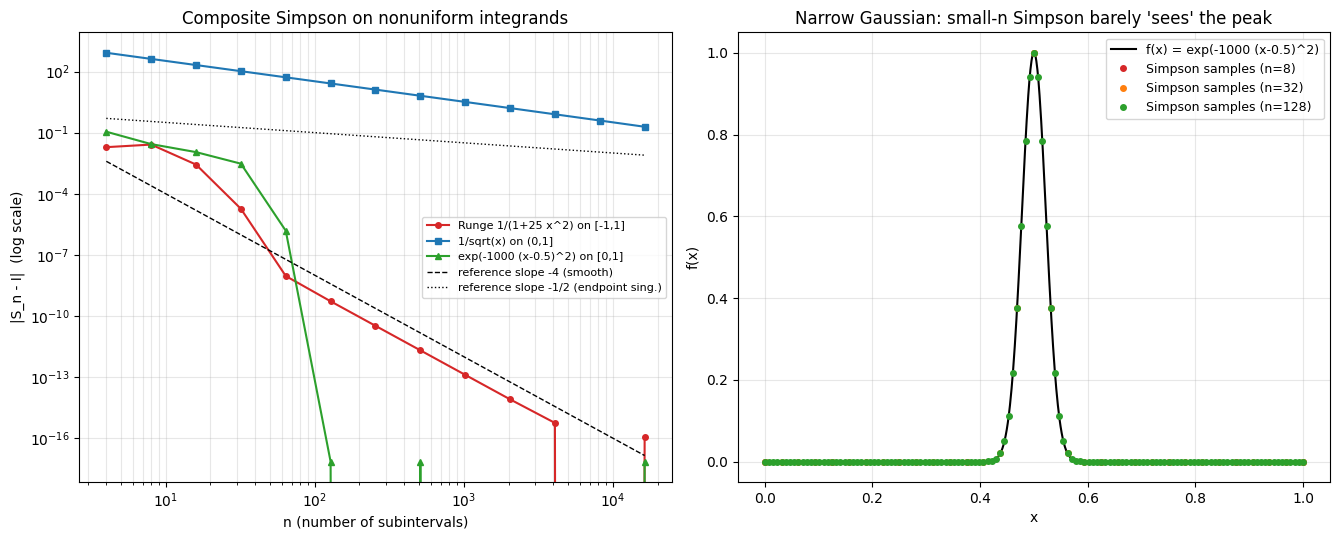

In [5]:
# 시각화: 세 함수의 Simpson 오차 + 좁은 Gaussian 의 표집 시각화
fig = plt.figure(figsize=(13.5, 5.5))

# 왼쪽: 세 함수의 오차 (log-log)
ax = fig.add_subplot(1, 2, 1)
styles = [("Runge 1/(1+25 x^2) on [-1,1]",         "o-",  "#d62728"),
          ("1/sqrt(x) on (0,1]",                    "s-",  "#1f77b4"),
          ("exp(-1000 (x-0.5)^2) on [0,1]",         "^-",  "#2ca02c")]
for name, marker, col in styles:
    df = frames[name]
    ax.loglog(df["n"], df["|error|"], marker, lw=1.5, ms=4, label=name, color=col)

n_ref = frames["Runge 1/(1+25 x^2) on [-1,1]"]["n"].astype(float)
ax.loglog(n_ref, 1.0 * (1.0 / n_ref) ** 4, "k--", lw=1, label="reference slope -4 (smooth)")
ax.loglog(n_ref, 1.0 * (1.0 / n_ref) ** 0.5, "k:",  lw=1, label="reference slope -1/2 (endpoint sing.)")
ax.set_xlabel("n (number of subintervals)")
ax.set_ylabel("|S_n - I|  (log scale)")
ax.set_title("Composite Simpson on nonuniform integrands")
ax.legend(fontsize=8); ax.grid(True, which="both", alpha=0.3)

# 오른쪽: 좁은 Gaussian 의 sampling 시각화
ax = fig.add_subplot(1, 2, 2)
xx = np.linspace(0, 1, 1000)
ax.plot(xx, np.exp(-1000.0 * (xx - 0.5) ** 2), "k-", lw=1.5, label="f(x) = exp(-1000 (x-0.5)^2)")
for n, c in zip([8, 32, 128], ["#d62728", "#ff7f0e", "#2ca02c"]):
    xs = np.linspace(0, 1, n + 1)
    ys = np.exp(-1000.0 * (xs - 0.5) ** 2)
    ax.plot(xs, ys, "o", ms=4, color=c, label=f"Simpson samples (n={n})")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("Narrow Gaussian: small-n Simpson barely 'sees' the peak")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **Runge** ($1/(1+25 x^2)$): tail slope 가 $-4.0$ 근처로 수렴 — *차수는 살아남는다*.
   다만 *상수* 가 매우 커서 같은 $n$ 에서 매끄러운 $\sin$/$\exp$ 보다 *수십 배* 더 부정확. peak 폭
   $\sim 1/5$ 보다 $h$ 가 작아지기 전까지는 *prefactor* 가 지배.
2. **$1/\sqrt x$**: tail slope 가 $-0.5$ 부근 — *Simpson 의 $\mathcal O(h^4)$ 가 깨진다*.
   끝점 미분 특이점이 Euler–Maclaurin 의 leading 항을 *지수 $\alpha+1 = 1/2$* 로 치환.
   같은 정확도를 위해 $n$ 이 *천문학적으로* 필요 — 즉 *균등 분할로는 사실상 풀 수 없는* 적분.
3. **좁은 Gaussian**: 작은 $n$ 에서 결과가 *0 에 가깝다* — 모든 표집점이 peak 의 *완전 바깥* 에 떨어진다.
   $n \gtrsim \sqrt{1000} \approx 32$ 가 되어서야 peak 안쪽 표집점이 생기고, *그제서야* Simpson 이
   의미 있는 추정을 시작한다. 그 전까지의 결과는 *우연한 0 에 가까운 값* — 오차는 작아 보여도
   *알고리즘이 사실상 작동하지 않은* 것이다 (위험한 false-positive).
4. **시각화** (오른쪽 패널): $n=8$ 표집은 peak 의 *어떤 점도* 만나지 못한다. $n=32$ 도 두세 점만 peak
   안쪽이고 나머지는 전부 $\approx 0$. *균등 분할은 정보를 균등하게 낭비한다.*

> **결론**: Simpson 의 $\mathcal O(h^4)$ 는 *부드러움 + 균등 표집* 의 가정 위에서만 성립.
> 어느 한 쪽이 깨지면 차수 자체가 무너지거나, 살아남더라도 *천문학적 상수* 가 붙는다.

**다음 (Problem 3)**: 이 모든 병리를 **적응형 Simpson** — 부분구간별로 *지역 오차를 추정* 해 잘게 쪼개는
재귀 알고리즘 — 으로 다스린다. Runge 의 peak 주변에는 잘게, 평평한 영역에는 성기게 — 같은 함수 평가 횟수로
*수 차수* 더 정확한 결과를 얻는다.
